# EOM Public API Exploration

This notebook exercises the public equation-of-motion (EOM) interface for the
drogued drifter model. It covers:

- Computing drag coefficients and added masses from geometry using the helper
  functions `drogue_horizontal_drag_coeff`, `buoy_horizontal_drag_coeff`,
  `drogue_horizontal_added_mass`, and `buoy_horizontal_added_mass`.
- Constructing a `DroguedDrifterPhysics` instance from those values.
- Constructing an `DroguedDrifterState` for a scenario where the surface current differs
  from the drogue-depth current.
- Evaluating M, F, and qdd via `_get_eom_callables` and verifying that
  `M @ qdd ≈ F` (sanity check on the EOM implementation).
- Batch evaluation over many states simultaneously.
- A parameter sensitivity sweep: how steady-state drift changes as the drogue
  width varies.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mechanical_drifters.models.drogued_drifter import (
    DroguedDrifter,
    DroguedDrifterPhysics,
    DroguedDrifterState,
    drogue_horizontal_added_mass,
    buoy_horizontal_added_mass,
    drogue_horizontal_drag_coeff,
    buoy_horizontal_drag_coeff,
)
from mechanical_drifters.eom import _get_eom_callables

## Parameters

In [2]:
# Sea water density
rho = 1025.0          # [kg/m^3]

# Drogue geometry
w_d = 0.5             # drogue plate width [m]
h_d = 0.5             # drogue plate height [m]

# Buoy geometry
d_b = 0.1             # buoy diameter [m]
h_b = 0.24            # buoy submerged height [m]

# Dry masses
m_b = 1.0             # buoy dry mass [kg]
m_d = 2.7             # drogue dry mass [kg]
m_hat_d = 1.0         # drogue buoyancy correction [kg]

# Pole length
l = 3.0               # [m]

# Gravitational acceleration
g = 9.81              # [m/s^2]

# Scenario currents
U_b = 0.5             # buoy (surface) current, east [m/s]
V_b = 0.0             # buoy (surface) current, north [m/s]
U_d = 0.0             # drogue-depth current, east [m/s]
V_d = 0.0             # drogue-depth current, north [m/s]

# Drogue width sweep
w_d_min = 0.2         # [m]
w_d_max = 1.0         # [m]
n_w_d = 9             # number of sweep points

## Drag coefficients and added masses from geometry

The four helper functions translate measurable geometry into the drag
coefficient and added-mass parameters required by `DroguedDrifterPhysics`. This keeps
the physics transparent: changing a geometric dimension (e.g. a wider drogue
plate) directly updates both the drag and added-mass terms in a physically
consistent way.

In [3]:
m_tilde_d = drogue_horizontal_added_mass(rho=rho, w_d=w_d, h_d=h_d)
m_tilde_b = buoy_horizontal_added_mass(rho=rho, d_b=d_b, h_b=h_b)
k_d = drogue_horizontal_drag_coeff(rho=rho, w_d=w_d, h_d=h_d)
k_b = buoy_horizontal_drag_coeff(rho=rho, d_b=d_b, h_b=h_b)

print(f"Drogue added mass  m_tilde_d = {m_tilde_d:.2f} kg")
print(f"Buoy added mass    m_tilde_b = {m_tilde_b:.4f} kg")
print(f"Drogue drag coeff  k_d       = {k_d:.2f} kg/m")
print(f"Buoy drag coeff    k_b       = {k_b:.4f} kg/m")

Drogue added mass  m_tilde_d = 100.63 kg
Buoy added mass    m_tilde_b = 1.9321 kg
Drogue drag coeff  k_d       = 153.75 kg/m
Buoy drag coeff    k_b       = 12.3000 kg/m


## Construct DroguedDrifterPhysics

`DroguedDrifterPhysics` is a frozen `NamedTuple` that holds all 9 physical parameters.
Once created it is passed (via the packer) to the lambdified EOM functions.

In [4]:
physics = DroguedDrifterPhysics(
    m_b=m_b,
    m_d=m_d,
    m_hat_d=m_hat_d,
    m_tilde_d=m_tilde_d,
    m_tilde_b=m_tilde_b,
    l=l,
    g=g,
    k_b=k_b,
    k_d=k_d,
)
print(physics)

DroguedDrifterPhysics(m_b=1.0, m_d=2.7, m_hat_d=1.0, m_tilde_d=100.62913968529806, m_tilde_b=1.932079481957723, l=3.0, g=9.81, k_b=12.299999999999999, k_d=153.75)


## Construct DroguedDrifterState and evaluate the EOM

`DroguedDrifterState` carries per-timestep kinematics (stereographic coordinates and their
velocities) plus the current velocities at buoy and drogue depths. Here the
drogue starts hanging straight down (stereographic coordinates `u_stereo =
v_stereo = 0`) and the system is at rest, so we are evaluating the
instantaneous acceleration felt the moment after a step-change in current.

In [5]:
state = DroguedDrifterState(
    u_stereo=0.0,
    v_stereo=0.0,
    xd=0.0,
    yd=0.0,
    ud_stereo=0.0,
    vd_stereo=0.0,
    U_b=U_b,
    V_b=V_b,
    U_d=U_d,
    V_d=V_d,
)

In [6]:
dd = DroguedDrifter(physics)
qdd_raw, M_raw, F_raw, pack_eom_args = _get_eom_callables(dd)

args = pack_eom_args(physics, state)
qdd = np.ravel(qdd_raw(*args))
M   = np.asarray(M_raw(*args), dtype=float)
F   = np.ravel(F_raw(*args))

print(f"qdd (generalized accelerations, shape {qdd.shape}):")
print(f"  xdd        = {qdd[0]:.6f} m/s^2   (buoy east acceleration)")
print(f"  ydd        = {qdd[1]:.6f} m/s^2   (buoy north acceleration)")
print(f"  ud_stereo  = {qdd[2]:.6f} 1/s^2   (stereographic u acceleration)")
print(f"  vd_stereo  = {qdd[3]:.6f} 1/s^2   (stereographic v acceleration)")
print()
print(f"M shape: {M.shape}")
print(f"F shape: {F.shape}")

qdd (generalized accelerations, shape (4,)):
  xdd        = 1.048744 m/s^2   (buoy east acceleration)
  ydd        = -0.000000 m/s^2   (buoy north acceleration)
  ud_stereo  = -0.349581 1/s^2   (stereographic u acceleration)
  vd_stereo  = 0.000000 1/s^2   (stereographic v acceleration)

M shape: (4, 4)
F shape: (4,)


## Verify M @ qdd ≈ F

The EOM have the form M·q̈ = F. After computing qdd = M⁻¹·F internally, we
can reconstruct F from M and qdd and compare.

In [7]:
residual = M @ qdd - F
max_residual = np.max(np.abs(residual))
print(f"Max |M @ qdd - F| = {max_residual:.2e}")
assert np.allclose(M @ qdd, F, atol=1e-10), f"Residual too large: {max_residual}"
print("M @ qdd ≈ F  [OK]")

Max |M @ qdd - F| = 1.01e-14
M @ qdd ≈ F  [OK]


## Batch evaluation

Pass arrays of length N instead of scalars to evaluate many states in one
call. Here we hold all kinematics fixed and sweep the surface current
eastward component across N values.

In [8]:
N = 20
U_b_sweep = np.linspace(0.0, 1.0, N)

state_batch = DroguedDrifterState(
    u_stereo=np.zeros(N),
    v_stereo=np.zeros(N),
    xd=np.zeros(N),
    yd=np.zeros(N),
    ud_stereo=np.zeros(N),
    vd_stereo=np.zeros(N),
    U_b=U_b_sweep,
    V_b=np.zeros(N),
    U_d=np.zeros(N),
    V_d=np.zeros(N),
)

args_batch = pack_eom_args(physics, state_batch)
qdd_batch = np.column_stack(qdd_raw(*args_batch))  # (N, 4)

# M_raw / F_raw return nested structures with mixed scalar / (N,) elements.
# Evaluate per particle to get clean (4,4) and (4,) arrays.
print(f"Batch qdd shape: {qdd_batch.shape}")

Batch qdd shape: (20, 4)


In [9]:
# Verify M @ qdd ≈ F for every particle in the batch.
residuals = []
for i in range(N):
    state_i = DroguedDrifterState(*(s[i] if hasattr(s, '__len__') else s for s in state_batch))
    args_i = pack_eom_args(physics, state_i)
    M_i = np.asarray(M_raw(*args_i), dtype=float)
    F_i = np.ravel(F_raw(*args_i))
    residuals.append(np.max(np.abs(M_i @ qdd_batch[i] - F_i)))

residuals = np.array(residuals)
print(f"Max |M @ qdd - F| across all batch entries: {residuals.max():.2e}")
assert np.all(residuals < 1e-10), "Batch residual too large"
print("M @ qdd ≈ F for all batch entries  [OK]")

Max |M @ qdd - F| across all batch entries: 2.55e-13
M @ qdd ≈ F for all batch entries  [OK]


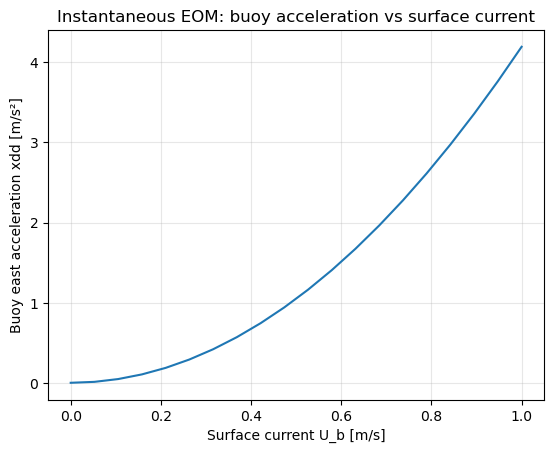

In [10]:
fig, ax = plt.subplots()
ax.plot(U_b_sweep, qdd_batch[:, 0])
ax.set_xlabel("Surface current U_b [m/s]")
ax.set_ylabel("Buoy east acceleration xdd [m/s²]")
ax.set_title("Instantaneous EOM: buoy acceleration vs surface current")
ax.grid(True, alpha=0.3)
plt.show()

## Parameter sensitivity: steady-state drift vs drogue width

A wider drogue plate increases both the drag coefficient and the added mass.
We sweep `w_d` and run the full ODE integrator to find the steady-state drift
speed, showing how much of the surface current the buoy follows.

In [11]:
w_d_values = np.linspace(w_d_min, w_d_max, n_w_d)

def make_step_sampler(U_b_val, V_b_val, U_d_val, V_d_val):
    """Return a sampler that gives surface current at z=0 and drogue current elsewhere."""
    def sample_uv(z):
        z_arr = np.atleast_1d(np.asarray(z, dtype=float))
        U = np.where(z_arr == 0.0, U_b_val, U_d_val)
        V = np.where(z_arr == 0.0, V_b_val, V_d_val)
        return U, V
    return sample_uv

In [12]:
xd_finals = []
k_d_values = []

for w in w_d_values:
    k_d_w = drogue_horizontal_drag_coeff(rho=rho, w_d=w, h_d=h_d)
    m_tilde_d_w = drogue_horizontal_added_mass(rho=rho, w_d=w, h_d=h_d)

    dd = DroguedDrifter(
        m_b=m_b,
        m_d=m_d,
        m_hat_d=m_hat_d,
        m_tilde_d=m_tilde_d_w,
        m_tilde_b=m_tilde_b,
        l=l,
        k_b=k_b,
        k_d=k_d_w,
        g=g,
    )
    t, Y, max_accel = dd.integrate(
        make_step_sampler(U_b, V_b, U_d, V_d), t_span=(0, 300),
    )
    drift_vel = dd.drift_velocity(Y[-1])
    xd_finals.append(float(drift_vel[0, 0]))
    k_d_values.append(k_d_w)

xd_finals = np.array(xd_finals)
k_d_values = np.array(k_d_values)

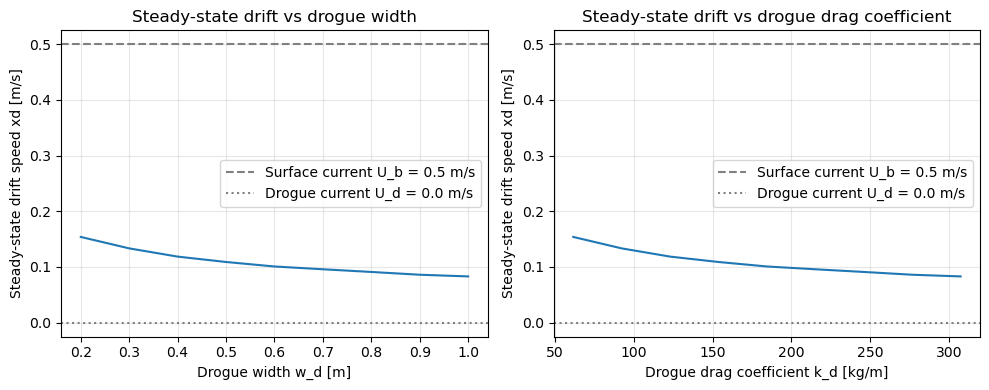

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(w_d_values, xd_finals)
axes[0].axhline(U_b, color="gray", linestyle="--", label=f"Surface current U_b = {U_b} m/s")
axes[0].axhline(U_d, color="gray", linestyle=":", label=f"Drogue current U_d = {U_d} m/s")
axes[0].set_xlabel("Drogue width w_d [m]")
axes[0].set_ylabel("Steady-state drift speed xd [m/s]")
axes[0].set_title("Steady-state drift vs drogue width")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_d_values, xd_finals)
axes[1].axhline(U_b, color="gray", linestyle="--", label=f"Surface current U_b = {U_b} m/s")
axes[1].axhline(U_d, color="gray", linestyle=":", label=f"Drogue current U_d = {U_d} m/s")
axes[1].set_xlabel("Drogue drag coefficient k_d [kg/m]")
axes[1].set_ylabel("Steady-state drift speed xd [m/s]")
axes[1].set_title("Steady-state drift vs drogue drag coefficient")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
print("Parameter sensitivity summary")
print(f"  Drogue width range:  {w_d_min:.2f} – {w_d_max:.2f} m")
print(f"  Drag coeff range:    {k_d_values.min():.1f} – {k_d_values.max():.1f} kg/m")
print(f"  Drift speed range:   {xd_finals.min():.4f} – {xd_finals.max():.4f} m/s")
print(f"  Surface current:     {U_b:.4f} m/s")
print(f"  Drogue current:      {U_d:.4f} m/s")
fraction_min = xd_finals.min() / U_b if U_b != 0 else float("nan")
fraction_max = xd_finals.max() / U_b if U_b != 0 else float("nan")
print(f"  Fraction of surface current followed: {fraction_min:.2%} – {fraction_max:.2%}")

Parameter sensitivity summary
  Drogue width range:  0.20 – 1.00 m
  Drag coeff range:    61.5 – 307.5 kg/m
  Drift speed range:   0.0830 – 0.1539 m/s
  Surface current:     0.5000 m/s
  Drogue current:      0.0000 m/s
  Fraction of surface current followed: 16.61% – 30.79%
